# Machine learning and neural network project
## By Tan Zheng Yi 230656633

## Dataset

This project will use the wine dataset from sklearn

## Algorithm 

The algorithms used in this project are:
   - K-Nearest Neighbor (KNN)
   - Logisitc Regression
   - Decision Tree

I will be doing KNN from scratch, the others will be using libraries

### *Import libraries* ###

In [205]:
from sklearn import datasets
import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.metrics import pairwise_distances
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.tree import DecisionTreeClassifier , plot_tree, export_text

# K-Nearest Neighbors #

## Steps: 
- Create KNN Class
- Load dataset
- Selecting the k value using hyperparameter tuning
- Visual feature selection via scatterplot matrix
- Comparsion
- Evaluate
- Scatterplot of 2 original features
- KNN decision boundary
- Accuracy score

### Create KNN Class

In [209]:
# Class
class KNNClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self,k=3, metric="Euclidean"):
        self.k = k
        self.metric = metric
    
    def fit(self, X, y):
        self.X_train_ = np.asarray(X)
        self.y_train_ = np.asarray(y)
        self.classes_ = np.unique(y) 
        return self

    def predict(self,X):
        X = np.asarray(X)
        y_pred = np.empty(X.shape[0], dtype=self.y_train_.dtype)

        for i, x in enumerate(X):
            #calculate distances using pairwise_distances
            d = pairwise_distances(self.X_train_, x[None, :], metric=self.metric).ravel()
            #sort distances and select K nearest neighbors
            J = np.argsort(d)[:self.k]
            #get the labels of the k nearest neighbors
            labels, counts = np.unique(self.y_train_[J], return_counts = True)
            # find the most common label among the k neighbors
            y_pred[i] = labels[np.argmax(counts)] #maj vote ; ties break by smallest label
            
        return y_pred

### Load Dataset

In [211]:
#Load the dataset
wine = datasets.load_wine()
#Convert to pandas dataframe for easier plotting
df = pd.DataFrame(wine.data, columns = wine.feature_names)
df['wine'] = wine.target

#setting the axis 
X = df.drop(['wine'], axis = 'columns')
y = df['wine']

df.head()
df.describe()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,wine
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258,0.938202
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474,0.775035
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000,0.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000,0.000000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000,1.000000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000,2.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000,2.000000


In [212]:
# Train-test split
# stratify to keep the test and train set rough the same distribution
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size = 0.2, random_state = 0,stratify = y)


In [213]:
#Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Hyperparameter Tuning

In [215]:
# Tune KNN parameters
k_values = [1, 3, 5, 7, 9, 11, 13, 15]
k_results = []

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for k in k_values:
    fold_scores = []
    
    for train_idx, val_idx in cv.split(X_train_scaled, y_train):
        X_train_fold = X_train_scaled[train_idx]
        X_val_fold = X_train_scaled[val_idx]
        y_train_fold = y_train.iloc[train_idx]
        y_val_fold = y_train.iloc[val_idx]
        
        knn = KNNClassifier(k=k, metric='euclidean')
        knn.fit(X_train_fold, y_train_fold)
        y_pred = knn.predict(X_val_fold)
        score = accuracy_score(y_val_fold, y_pred)
        fold_scores.append(score)
    
    mean_score = np.mean(fold_scores)
    std_score = np.std(fold_scores)
    k_results.append({'k': k, 'mean': mean_score, 'std': std_score})
    print(f"  k={k:2d}: {mean_score:.3f} ± {std_score:.3f}")

# Find optimal k
best_k_result = max(k_results, key=lambda x: x['mean'])
optimal_k = best_k_result['k']
print(f"\n Optimal k for KNN: {optimal_k}")
print(f"   CV Accuracy: {best_k_result['mean']:.3f}")

  k= 1: 0.931 ± 0.065
  k= 3: 0.930 ± 0.038
  k= 5: 0.944 ± 0.027
  k= 7: 0.944 ± 0.035
  k= 9: 0.951 ± 0.035
  k=11: 0.972 ± 0.026
  k=13: 0.951 ± 0.017
  k=15: 0.965 ± 0.031

 Optimal k for KNN: 11
   CV Accuracy: 0.972


In [216]:
#Calling our KNN class
distance_metric = "euclidean"
knn_optimal = KNNClassifier(k=optimal_k, metric= distance_metric)
knn_optimal.fit(X_train_scaled,y_train)

y_pred = knn_optimal.predict(X_test_scaled)
y_pred

array([1, 0, 1, 0, 1, 2, 2, 0, 1, 0, 2, 2, 0, 2, 1, 0, 2, 2, 1, 0, 0, 2,
       2, 1, 2, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1])

In [217]:
acc_13 =  accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=wine.target_names))

Accuracy: 0.9722222222222222
              precision    recall  f1-score   support

     class_0       0.92      1.00      0.96        12
     class_1       1.00      0.93      0.96        14
     class_2       1.00      1.00      1.00        10

    accuracy                           0.97        36
   macro avg       0.97      0.98      0.97        36
weighted avg       0.97      0.97      0.97        36



### Visual feature Selection via pairplot 13x13

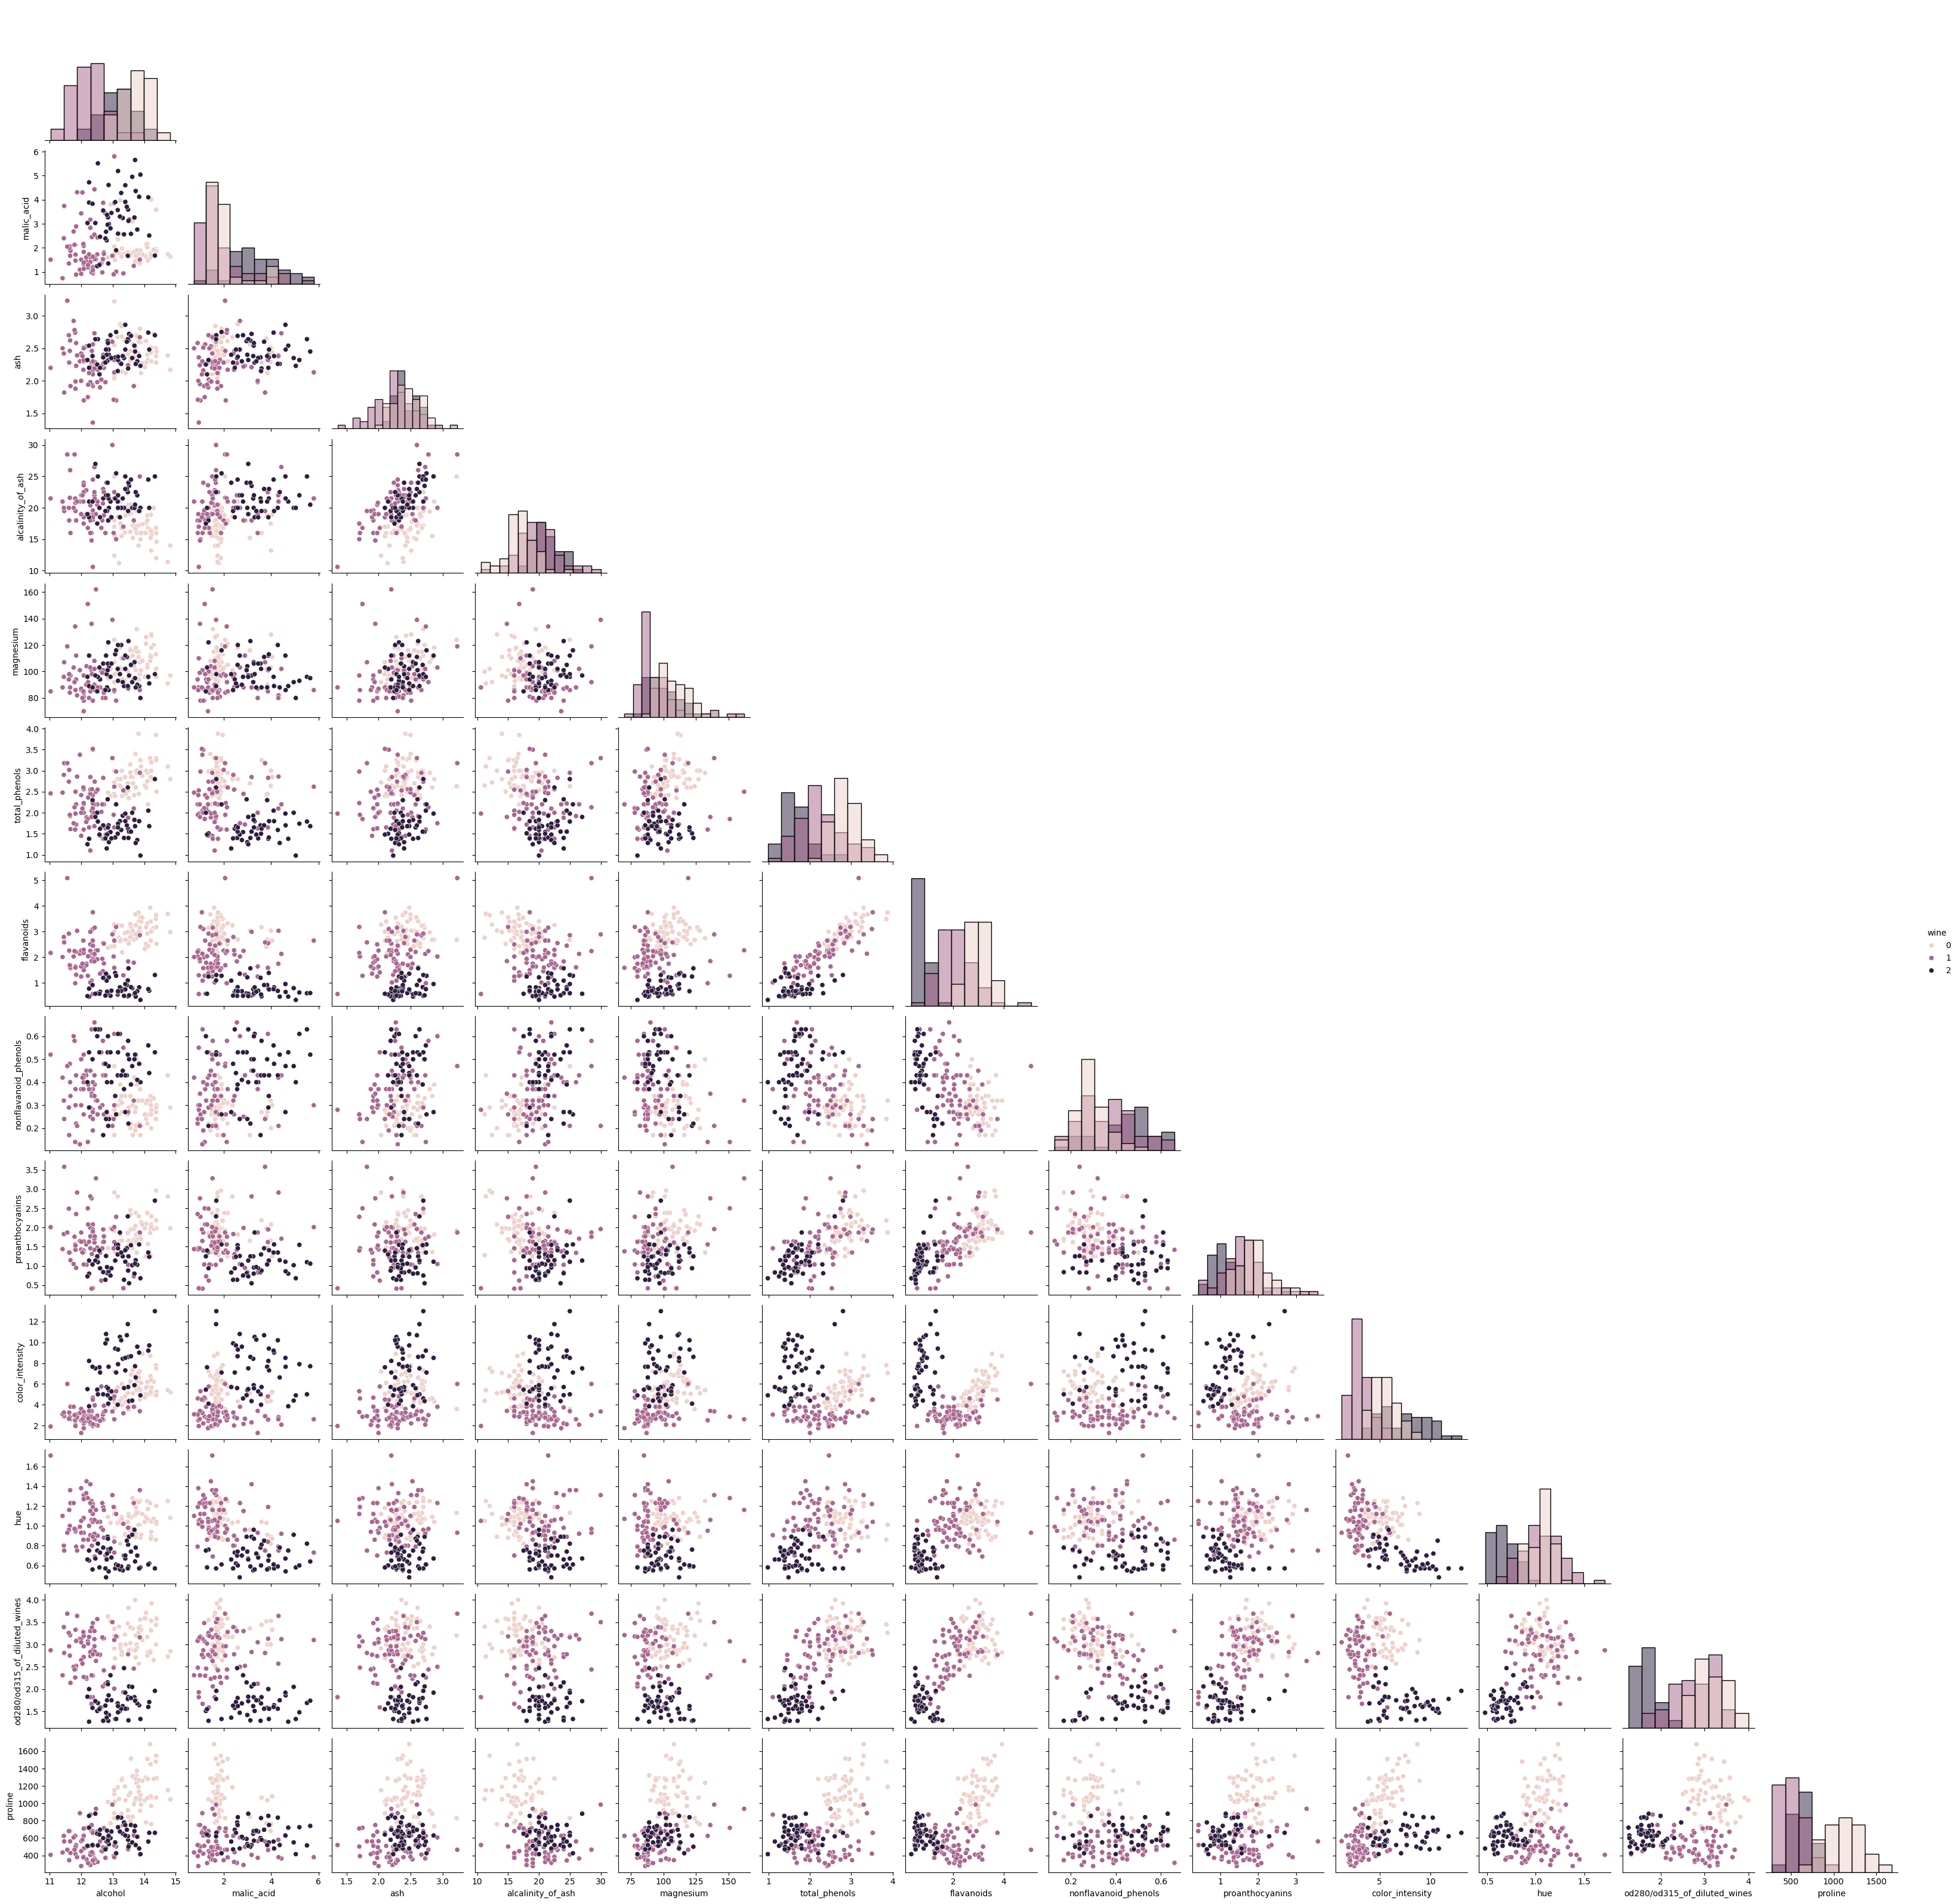

In [219]:
import seaborn as sns

#Pairplot 13x13
sns.pairplot(df,hue='wine',corner=True, diag_kind='hist')

To select which of these pairplots to choose , there are a few methods to decide:
- best class separation visually
- selecting most important features
- correlation with target label 

For the pairs with the best class separation visual are:
- Flavanoids vs OD280/OD315
- Color intensity vs Hue
- Alcohol vs Flavanoids

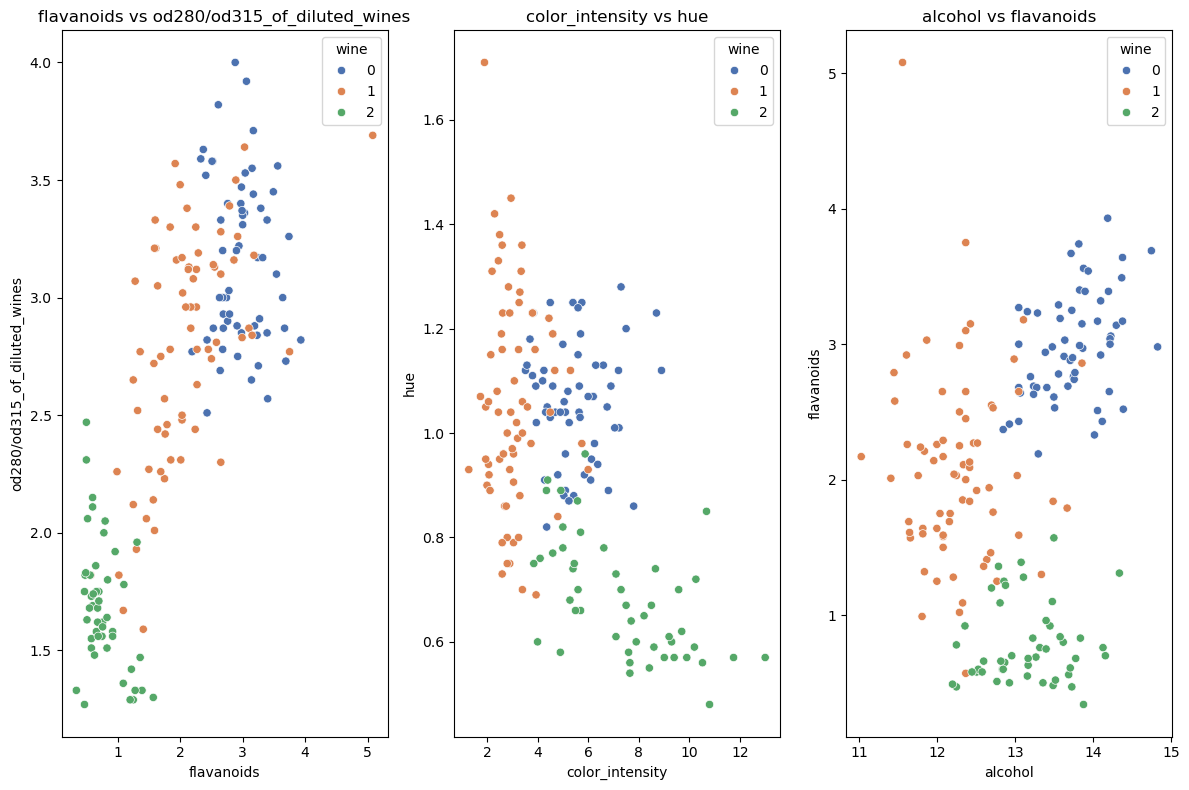

In [222]:
pairs = [
    ("flavanoids", "od280/od315_of_diluted_wines"),
    ("color_intensity", "hue"),
    ("alcohol", "flavanoids")
]

plt.figure(figsize=(12,8))

for i, (x, y) in enumerate(pairs):
    plt.subplot(1, 3, i+1)
    sns.scatterplot(data=df, x=x, y=y, hue="wine", palette="deep")
    plt.title(f"{x} vs {y}")

plt.tight_layout()
plt.show()

In [223]:
# 2nd method
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42)
model.fit(X,df['wine'])
importances = model.feature_importances_

sorted_idx = np.argsort(importances)[::-1]
top2 = sorted_idx[:2]
feature_names = X.columns

for i in sorted_idx:
    print(feature_names[i], ":", importances[i])


flavanoids : 0.19448065497563605
color_intensity : 0.1729611145944593
alcohol : 0.14161428299811962
proline : 0.1370454123515224
od280/od315_of_diluted_wines : 0.11183089019193483
hue : 0.07693904064266104
total_phenols : 0.03508046762610704
malic_acid : 0.033059652025652426
alcalinity_of_ash : 0.02988475827441192
magnesium : 0.0258726446973373
proanthocyanins : 0.018386807918194432
ash : 0.015533939876529991
nonflavanoid_phenols : 0.007310333827433746


From the results you can see the top 3 feautes based on importances are:
- flavanoids
- color intensity
- alcohol

In [225]:
# 3rd method correlating with the target label
corr = df.corr()['wine']
# Absolute value
corr.abs().sort_values(ascending=False)

wine                            1.000000
flavanoids                      0.847498
od280/od315_of_diluted_wines    0.788230
total_phenols                   0.719163
proline                         0.633717
hue                             0.617369
alcalinity_of_ash               0.517859
proanthocyanins                 0.499130
nonflavanoid_phenols            0.489109
malic_acid                      0.437776
alcohol                         0.328222
color_intensity                 0.265668
magnesium                       0.209179
ash                             0.049643
Name: wine, dtype: float64

The correlation absolute value shows that flavanoids and od280 are the strongest 2 features.

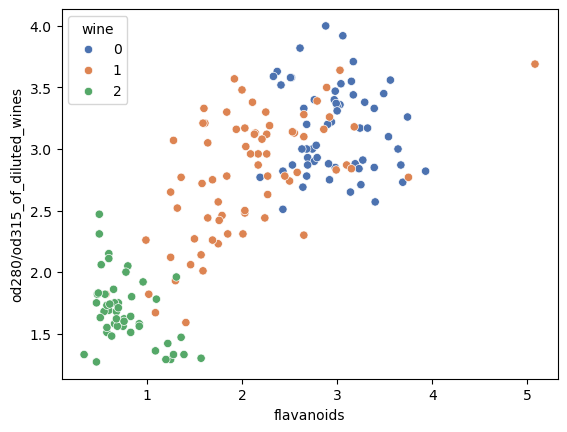

In [227]:
sns.scatterplot(data=df, x="flavanoids", y="od280/od315_of_diluted_wines",
                hue="wine", palette="deep")
plt.show()

### The conclusion of pairplot

The 2 strongest features are shown by the different methods are flavanoids and od280.

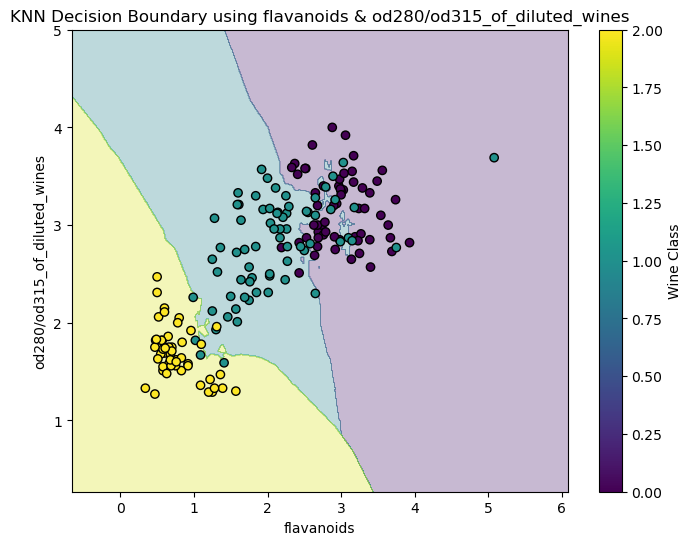

In [229]:
# Decision boundary
feature_x = "flavanoids"
feature_y = "od280/od315_of_diluted_wines"

X2 = df[[feature_x, feature_y]].values
y = df['wine'].values


# Train KNN

knn = KNNClassifier(k=5, metric= distance_metric)
knn.fit(X2, y)


x_min, x_max = X2[:,0].min() - 1, X2[:,0].max() + 1
y_min, y_max = X2[:,1].min() - 1, X2[:,1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 500),
    np.linspace(y_min, y_max, 500)
)

# Predict for every point on the grid
grid_points = np.c_[xx.ravel(), yy.ravel()]
Z = knn.predict(grid_points)
Z = Z.reshape(xx.shape)


# Plot Decision Boundary

plt.figure(figsize=(8,6))

# Filled contour for decision regions
plt.contourf(xx, yy, Z, alpha=0.3, cmap='viridis')

# Scatter the real data points
plt.scatter(X2[:,0], X2[:,1], c=y, cmap='viridis', edgecolor='k')

plt.xlabel(feature_x)
plt.ylabel(feature_y)
plt.title(f"KNN Decision Boundary using {feature_x} & {feature_y}")
plt.colorbar(label="Wine Class")
plt.show()

In [230]:
# Separate train
X2_train = X_train[['flavanoids', 'od280/od315_of_diluted_wines']]
X2_test  = X_test[['flavanoids', 'od280/od315_of_diluted_wines']]

# Scale
scaler = StandardScaler()
X2_train_scaled = scaler.fit_transform(X2_train)
X2_test_scaled  = scaler.transform(X2_test)

# Train knn 
knn_2 =  KNNClassifier(k=5, metric= distance_metric)
knn_2.fit(X2_train_scaled, y_train)

# Accuracy of top 2 features
y_pred_2 = knn_2.predict(X2_test_scaled)
acc_2 = accuracy_score(y_test, y_pred_2)
print("Accuracy (2 features):", acc_2)
print(classification_report(y_test, y_pred_2, target_names=wine.target_names))

Accuracy (2 features): 0.8888888888888888
              precision    recall  f1-score   support

     class_0       0.80      1.00      0.89        12
     class_1       1.00      0.71      0.83        14
     class_2       0.91      1.00      0.95        10

    accuracy                           0.89        36
   macro avg       0.90      0.90      0.89        36
weighted avg       0.91      0.89      0.88        36



## Principal Component Analysis

PCA is a dimension reduction technique used to transform high dimensional datasets into a lower one while prevsering as much information as possible.

The wine datasets has 13 featsures and plotting all 13 would be visually impossible so PCA is used to compress the data to a 2 dimensional space while keeping the major structure intact.

## Standalone PCA

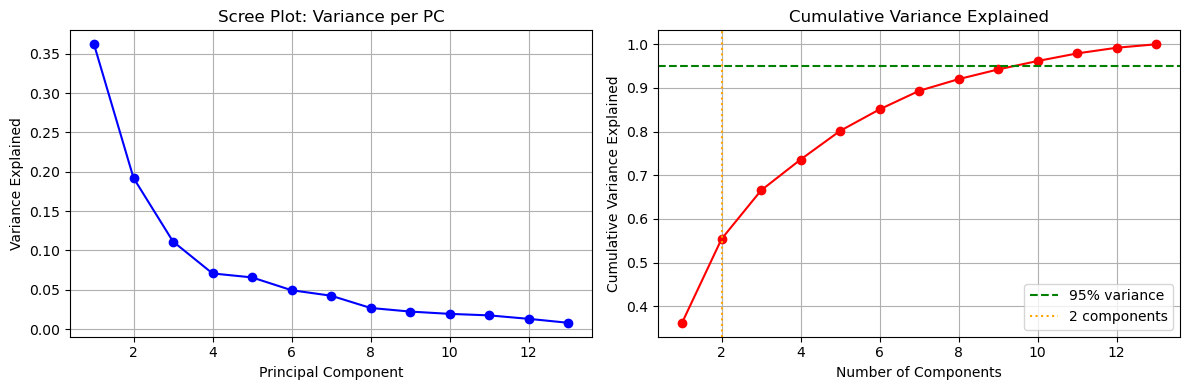

Variance explained by first 2 components: 55.41%
Components needed for 95% variance: 10


In [233]:
# STANDALONE PCA ANALYSIS


# Use ALL data for PCA (unsupervised, no labels needed)
X_scaled_all = scaler.fit_transform(X)

# 1. Determine optimal number of components
pca_full = PCA()
pca_full.fit(X_scaled_all)

# Scree plot
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(range(1, 14), pca_full.explained_variance_ratio_, 'bo-')
plt.xlabel('Principal Component')
plt.ylabel('Variance Explained')
plt.title('Scree Plot: Variance per PC')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(range(1, 14), np.cumsum(pca_full.explained_variance_ratio_), 'ro-')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Variance Explained')
plt.axhline(y=0.95, color='g', linestyle='--', label='95% variance')
plt.axvline(x=2, color='orange', linestyle=':', label='2 components')
plt.legend()
plt.title('Cumulative Variance Explained')
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"Variance explained by first 2 components: {sum(pca_full.explained_variance_ratio_[:2]):.2%}")
print(f"Components needed for 95% variance: {np.argmax(np.cumsum(pca_full.explained_variance_ratio_) >= 0.95) + 1}")

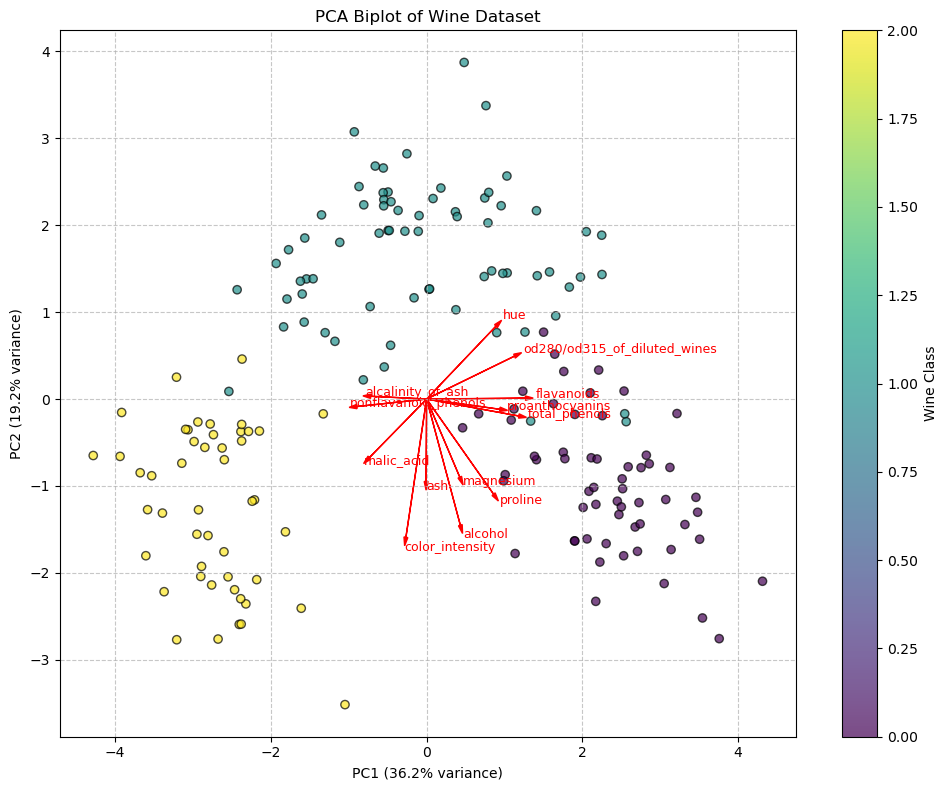

In [234]:
# Create PCA with 2 components for visualization
pca_2 = PCA(n_components=2)
X_pca_2 = pca_2.fit_transform(X_scaled_all)

# Create biplot
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_pca_2[:, 0], X_pca_2[:, 1], 
                     c=y, cmap='viridis', alpha=0.7, edgecolor='k')
plt.xlabel(f'PC1 ({pca_2.explained_variance_ratio_[0]:.1%} variance)')
plt.ylabel(f'PC2 ({pca_2.explained_variance_ratio_[1]:.1%} variance)')
plt.title('PCA Biplot of Wine Dataset')
plt.colorbar(scatter, label='Wine Class')

# Add feature vectors (loadings)
feature_vectors = pca_2.components_.T * 3  # Scale for visibility
feature_names = X.columns

for i, (vec, name) in enumerate(zip(feature_vectors, feature_names)):
    plt.arrow(0, 0, vec[0], vec[1], 
              head_width=0.05, head_length=0.1, fc='red', ec='red')
    plt.text(vec[0]*1.1, vec[1]*1.1, name, color='red', fontsize=9)

plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


PCA Loadings (Feature Contributions):
                                   PC1       PC2
alcohol                       0.144329 -0.483652
malic_acid                   -0.245188 -0.224931
ash                          -0.002051 -0.316069
alcalinity_of_ash            -0.239320  0.010591
magnesium                     0.141992 -0.299634
total_phenols                 0.394661 -0.065040
flavanoids                    0.422934  0.003360
nonflavanoid_phenols         -0.298533 -0.028779
proanthocyanins               0.313429 -0.039302
color_intensity              -0.088617 -0.529996
hue                           0.296715  0.279235
od280/od315_of_diluted_wines  0.376167  0.164496
proline                       0.286752 -0.364903


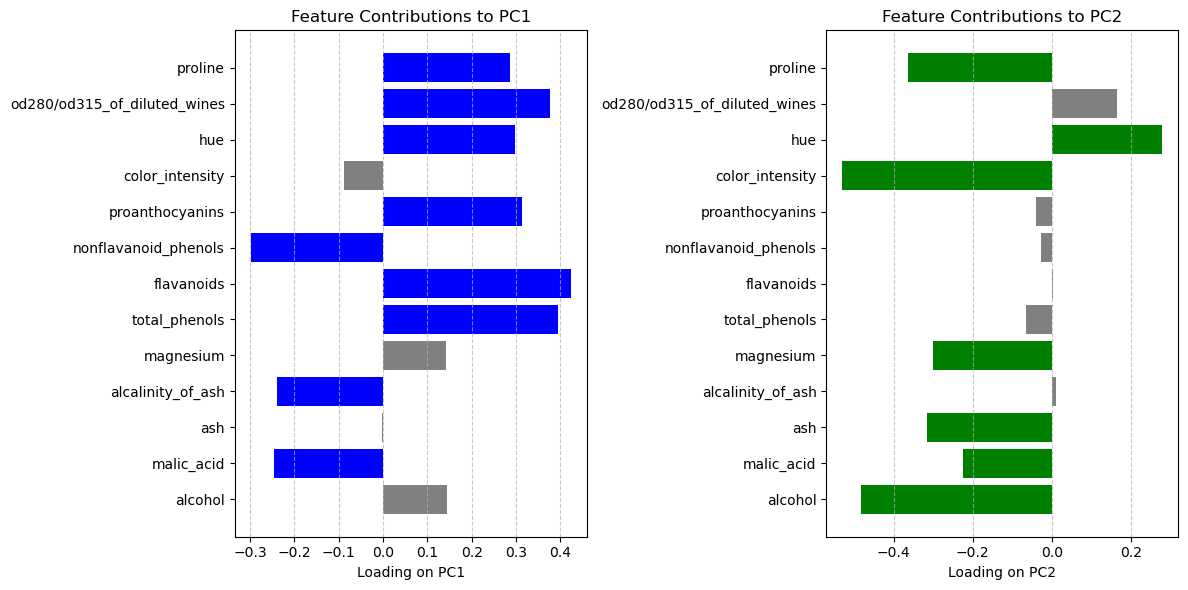


Top features for PC1:
flavanoids                      0.422934
total_phenols                   0.394661
od280/od315_of_diluted_wines    0.376167
proanthocyanins                 0.313429
nonflavanoid_phenols            0.298533
Name: PC1, dtype: float64

Top features for PC2:
color_intensity    0.529996
alcohol            0.483652
proline            0.364903
ash                0.316069
magnesium          0.299634
Name: PC2, dtype: float64


In [235]:
# Analyze which original features contribute to each PC
loadings = pd.DataFrame(
    pca_2.components_.T,
    columns=['PC1', 'PC2'],
    index=X.columns
)

print("\nPCA Loadings (Feature Contributions):")
print("=" * 50)
print(loadings)

# Plot feature contributions
plt.figure(figsize=(12, 6))
colors = ['blue' if abs(x) > 0.2 else 'gray' for x in loadings['PC1']]
plt.subplot(1, 2, 1)
plt.barh(loadings.index, loadings['PC1'], color=colors)
plt.xlabel('Loading on PC1')
plt.title('Feature Contributions to PC1')
plt.grid(axis='x', linestyle='--', alpha=0.7)

colors = ['green' if abs(x) > 0.2 else 'gray' for x in loadings['PC2']]
plt.subplot(1, 2, 2)
plt.barh(loadings.index, loadings['PC2'], color=colors)
plt.xlabel('Loading on PC2')
plt.title('Feature Contributions to PC2')
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# Identify most influential features for each PC
print("\nTop features for PC1:")
print(loadings['PC1'].abs().sort_values(ascending=False).head(5))
print("\nTop features for PC2:")
print(loadings['PC2'].abs().sort_values(ascending=False).head(5))

In [236]:
# Compare PCA findings with earlier feature selection

# 1. Random Forest importance
rf_important = ['flavanoids', 'color_intensity', 'alcohol']

# 2. Correlation with target 
corr_important = ['flavanoids', 'od280/od315_of_diluted_wines', 'total_phenols']

# 3. PCA loadings (new)
pca_pc1_important = loadings['PC1'].abs().nlargest(3).index.tolist()
pca_pc2_important = loadings['PC2'].abs().nlargest(3).index.tolist()

comparison_df = pd.DataFrame({
    'Method': ['Random Forest', 'Correlation with Target', 'PCA (PC1)', 'PCA (PC2)'],
    'Top 3 Features': [
        rf_important,
        corr_important,
        pca_pc1_important,
        pca_pc2_important
    ],
    'Goal': [
        'Predictive power',
        'Linear relationship with target',
        'Maximum variance direction',
        'Second orthogonal variance direction'
    ]
})

print(comparison_df.to_string(index=False))

                 Method                                            Top 3 Features                                 Goal
          Random Forest                    [flavanoids, color_intensity, alcohol]                     Predictive power
Correlation with Target [flavanoids, od280/od315_of_diluted_wines, total_phenols]      Linear relationship with target
              PCA (PC1) [flavanoids, total_phenols, od280/od315_of_diluted_wines]           Maximum variance direction
              PCA (PC2)                       [color_intensity, alcohol, proline] Second orthogonal variance direction


# Decision Tree

### Steps
- prepare the dataset
- train-test split
- Hyperparameter tuning
- train decision tree
- make predictions
- evaluate
- class report
- feature importances
- plot

A Decision Tree classifier works by recursively splitting the dataset into smaller subsets based on features that provide the highest information gain. At each node, the algorithm chooses the feature and threshold that best separates the classes. This creates a tree-like structure of decision rules. Decision Trees are highly interpretable because each classification corresponds to a simple sequence of conditions. However, they may overfit if the tree becomes too deep, so pruning or depth limits are often used.

In [240]:
# Hyperparameter tuning
# Use GridSearchCV for Decision Tree
dt_params = {
    'max_depth': list(range(1, 10)),
    'min_samples_split': [2, 4, 8, 16, 32],
    'criterion': ['gini', 'entropy']
}

dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    dt_params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=0
)

dt_grid.fit(X_train, y_train)

print(f"  Best Parameters:")
print(f"    max_depth: {dt_grid.best_params_['max_depth']}")
print(f"    min_samples_split: {dt_grid.best_params_['min_samples_split']}")
print(f"    criterion: {dt_grid.best_params_['criterion']}")
print(f"  Best CV Accuracy: {dt_grid.best_score_:.3f}")

optimal_dt_params = dt_grid.best_params_

  Best Parameters:
    max_depth: 4
    min_samples_split: 2
    criterion: entropy
  Best CV Accuracy: 0.944


In [241]:
dt_optimal = DecisionTreeClassifier(
    criterion=dt_grid.best_params_['criterion'],
    random_state=42,
    max_depth=dt_grid.best_params_['max_depth']   
)

dt_optimal.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=4, random_state=42)

In [242]:
y_pred_dt = dt_optimal.predict(X_test)

In [243]:
acc_dt = accuracy_score(y_test, y_pred_dt)
print("Decision Tree Accuracy:", acc_dt)

Decision Tree Accuracy: 0.9166666666666666


In [244]:
target_names = ["Class 0", "Class 1", "Class 2"]
print(classification_report(y_test, y_pred_dt, target_names=target_names))


              precision    recall  f1-score   support

     Class 0       1.00      0.83      0.91        12
     Class 1       0.82      1.00      0.90        14
     Class 2       1.00      0.90      0.95        10

    accuracy                           0.92        36
   macro avg       0.94      0.91      0.92        36
weighted avg       0.93      0.92      0.92        36



In [245]:
importances = dt_optimal.feature_importances_

for name, score in sorted(
        zip(X.columns, importances), key=lambda x: x[1], reverse=True):
    print(name, "=", score)

flavanoids = 0.43035916775747524
proline = 0.339451778925081
color_intensity = 0.13793193029171436
alcohol = 0.07324276324518061
magnesium = 0.01901435978054879
malic_acid = 0.0
ash = 0.0
alcalinity_of_ash = 0.0
total_phenols = 0.0
nonflavanoid_phenols = 0.0
proanthocyanins = 0.0
hue = 0.0
od280/od315_of_diluted_wines = 0.0


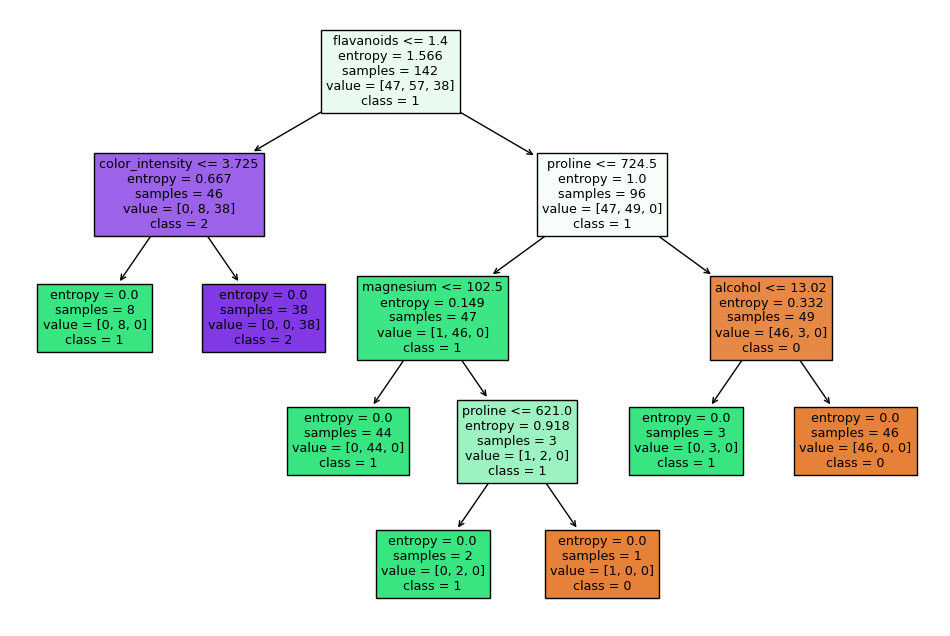

In [246]:
from sklearn import tree
plt.figure(figsize=(12,8))
tree.plot_tree(dt_optimal, feature_names=X.columns, class_names=["0","1","2"], filled=True)
plt.show()

## Observation
Based on the decision tree above, the stongest feature is the flavanoid, dividing the samples at 1.4. The tree splits to color_intensity on the left, where it splits at the value of 3.725. Proline on the right at the value of 724.5 it splits again.

these are the top 3 features which is different from the knn top 2 feature of falvanoids and ode280, where ode280 is no where in the tree making it not that influential based on the decision tree.

A Decision Tree classifier was trained on all 13 wine features without requiring scaling. The model recursively split the data based on the features that maximised information gain, creating a set of interpretable if–then rules. The tree achieved high classification accuracy and identified flavanoids, color intensity, and OD280/OD315 as the most influential features. Its performance serves as a useful comparison with distance-based KNN models and PCA-driven dimensionality reduction.

## Cross validation

In [250]:
# Set up 5-fold stratified cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [251]:
#5-FOLD CROSS-VALIDATION WITH KNN

# Prepare feature sets
scaler_all = StandardScaler()
X_all_scaled = scaler_all.fit_transform(X)

#collect scores in a list
knn_13_scores_list = []

scaler_top2 = StandardScaler()
X_top2 = X[['flavanoids', 'od280/od315_of_diluted_wines']].values
X_top2_scaled = scaler_top2.fit_transform(X_top2)

In [252]:
# Manual Cross-Validation for KNN

for fold, (train_idx, val_idx) in enumerate(cv.split(X_all_scaled, y), 1):
    # Split data for this fold
    X_train_fold = X_all_scaled[train_idx]
    X_val_fold = X_all_scaled[val_idx]
    y_train_fold = y[train_idx]
    y_val_fold = y[val_idx]
    
    # Train KNN with optimal k
    knn = KNNClassifier(k=optimal_k, metric='euclidean')
    knn.fit(X_train_fold, y_train_fold)
    
    # Predict and calculate accuracy
    y_pred_fold = knn.predict(X_val_fold)
    score = accuracy_score(y_val_fold, y_pred_fold)
    knn_13_scores_list.append(score)
    
    print(f"   Fold {fold}: {score:.3f}")

# Convert list to numpy array
knn_13_scores = np.array(knn_13_scores_list)
print(f"\n   CV Mean: {knn_13_scores.mean():.3f}")
print(f"   CV Std: {knn_13_scores.std():.3f}")
print(f"   Test Accuracy (from earlier): {acc_13:.3f}")
print(f"   Difference (Test - CV): {acc_13 - knn_13_scores.mean():.3f}")


   Fold 1: 0.944
   Fold 2: 0.972
   Fold 3: 1.000
   Fold 4: 0.943
   Fold 5: 0.971

   CV Mean: 0.966
   CV Std: 0.021
   Test Accuracy (from earlier): 0.972
   Difference (Test - CV): 0.006


In [253]:
# CV for KNN with top 2 features
print("\n2. Manual 5-Fold CV for KNN (top 2 features):")
knn_2_scores_list = []

for train_idx, val_idx in cv.split(X_top2_scaled, y):
    X_train_cv, X_val_cv = X_top2_scaled[train_idx], X_top2_scaled[val_idx]
    y_train_cv, y_val_cv = y[train_idx], y[val_idx]
    
    knn_cv = KNNClassifier(k=5, metric='euclidean')
    knn_cv.fit(X_train_cv, y_train_cv)
    y_pred_cv = knn_cv.predict(X_val_cv)
    score = accuracy_score(y_val_cv, y_pred_cv)
    knn_2_scores_list.append(score)

knn_2_scores = np.array(knn_2_scores_list)
print("\nKNN (2 features)")
print(f"   CV Mean: {knn_2_scores.mean():.3f}")
print(f"   CV Std: {knn_2_scores.std():.3f}")
print(f"   Test Accuracy: {acc_2:.3f}")
print(f"   Overfitting Gap (Test - CV): {acc_2 - knn_2_scores.mean():.3f}")


2. Manual 5-Fold CV for KNN (top 2 features):

KNN (2 features)
   CV Mean: 0.837
   CV Std: 0.032
   Test Accuracy: 0.889
   Overfitting Gap (Test - CV): 0.052


In [254]:
# CV for DT
dt_cv_scores = cross_val_score(
    dt_optimal,
    X,
    y,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1
)

print("\nDecision Tree")
print(f"   CV Mean: {dt_cv_scores.mean():.3f}")
print(f"   CV Std: {dt_cv_scores.std():.3f}")
print(f"   Test Accuracy: {acc_dt:.3f}")
print(f"   Overfitting Gap (Test - CV): {acc_dt - dt_cv_scores.mean():.3f}")



Decision Tree
   CV Mean: 0.910
   CV Std: 0.064
   Test Accuracy: 0.917
   Overfitting Gap (Test - CV): 0.007



COMPARISON TABLE:
                  Model  CV Mean Accuracy   CV Std  Test Accuracy  Overfitting Gap
KNN (k=11, 13 features)          0.966190 0.021091       0.972222         0.006032
 KNN (k=11, 2 features)          0.837143 0.032083       0.888889         0.051746
Decision Tree (depth=4)          0.909524 0.063728       0.916667         0.007143


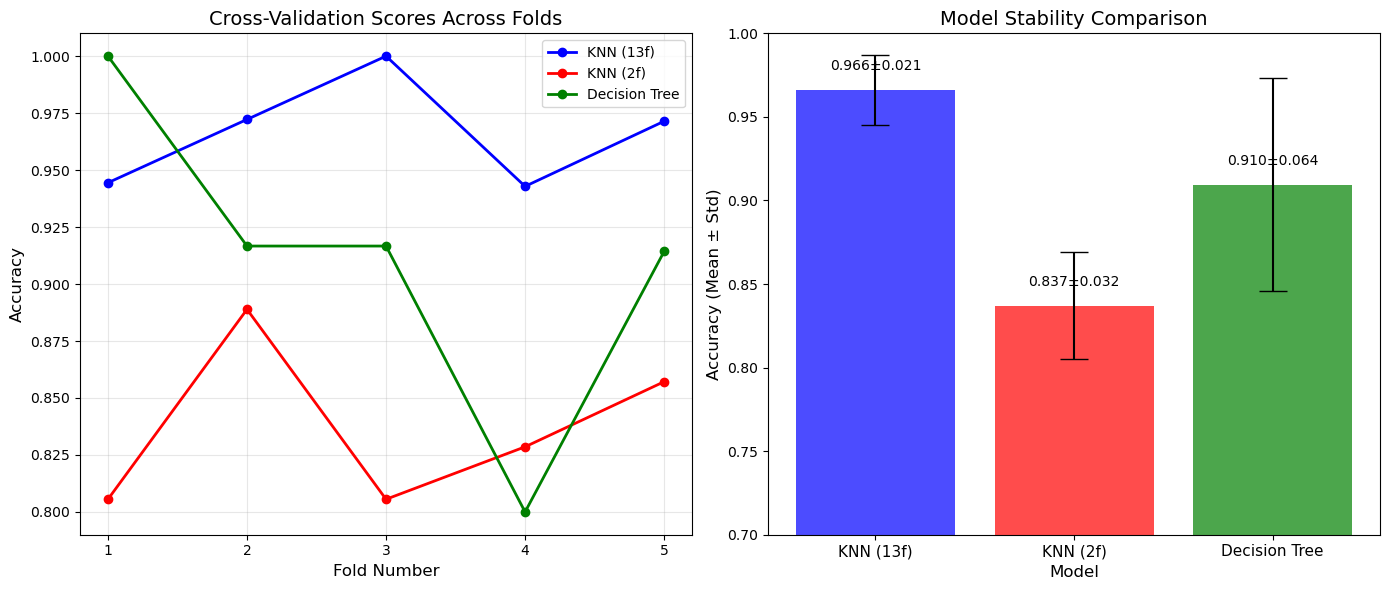

In [255]:
# Create results table
results_df = pd.DataFrame({
    'Model': [
        f'KNN (k={optimal_k}, 13 features)',
        f'KNN (k={optimal_k}, 2 features)',
        f'Decision Tree (depth={optimal_dt_params.get("max_depth", "N/A")})'
    ],
    'CV Mean Accuracy': [
        knn_13_scores.mean(),  
        knn_2_scores.mean(),   
        dt_cv_scores.mean()
    ],
    'CV Std': [
        knn_13_scores.std(),   
        knn_2_scores.std(),    
        dt_cv_scores.std()
    ],
    'Test Accuracy': [
        acc_13,
        acc_2,
        acc_dt
    ],
    'Overfitting Gap': [
        acc_13 - knn_13_scores.mean(),
        acc_2 - knn_2_scores.mean(),
        acc_dt - dt_cv_scores.mean()
    ]
})

print("\nCOMPARISON TABLE:")
print(results_df.to_string(index=False))

# Plot the results
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: CV scores per fold
fold_numbers = [1, 2, 3, 4, 5]
axes[0].plot(fold_numbers, knn_13_scores, 'bo-', label=f'KNN (13f)', linewidth=2)
axes[0].plot(fold_numbers, knn_2_scores, 'ro-', label='KNN (2f)', linewidth=2)
axes[0].plot(fold_numbers, dt_cv_scores, 'go-', label='Decision Tree', linewidth=2)

axes[0].set_xlabel('Fold Number', fontsize=12)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].set_title('Cross-Validation Scores Across Folds', fontsize=14)
axes[0].set_xticks(fold_numbers)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Mean ± Std comparison
models_short = ['KNN (13f)', 'KNN (2f)', 'Decision Tree']
x_pos = np.arange(len(models_short))
means = [knn_13_scores.mean(), knn_2_scores.mean(), dt_cv_scores.mean()]
stds = [knn_13_scores.std(), knn_2_scores.std(), dt_cv_scores.std()]

bars = axes[1].bar(x_pos, means, yerr=stds, capsize=10, alpha=0.7,
                   color=['blue', 'red', 'green'])

axes[1].set_xlabel('Model', fontsize=12)
axes[1].set_ylabel('Accuracy (Mean ± Std)', fontsize=12)
axes[1].set_title('Model Stability Comparison', fontsize=14)
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(models_short, fontsize=11)
axes[1].set_ylim(0.7, 1.0)

# Add value labels on bars
for bar, mean, std in zip(bars, means, stds):
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2, height + 0.01,
                f'{mean:.3f}±{std:.3f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

### Comparison of all three methods


                  Model                                     Hyperparameters  Test Accuracy                                Key Insight
KNN (k=11, 13 features)                              k=11, metric=euclidean       0.972222            Optimized KNN with all features
 KNN (k=11, 2 features)                              k=11, metric=euclidean       0.888889       Optimized KNN with feature selection
Decision Tree (depth=4) max_depth=4, min_samples_split=2, criterion=entropy       0.916667 Tuned Decision Tree (prevents overfitting)


Decision Tree Visualization (Tuned):


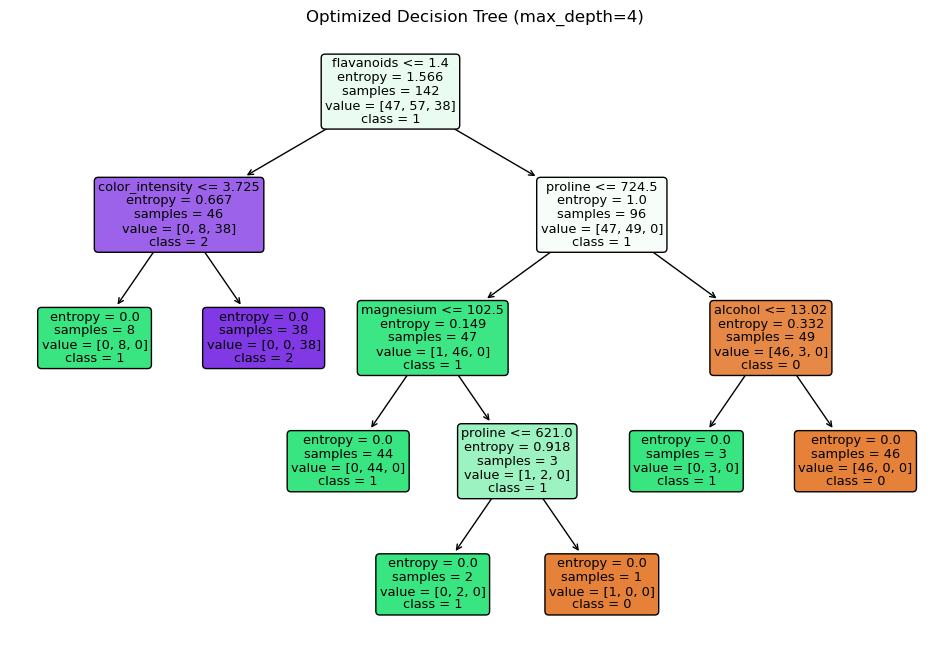

In [257]:
# FINAL MODEL COMPARISON

results = pd.DataFrame({
    "Model": [
        f"KNN (k={optimal_k}, 13 features)",
        f"KNN (k={optimal_k}, 2 features)",
        f"Decision Tree (depth={optimal_dt_params['max_depth']})"
    ],
    "Hyperparameters": [
        f"k={optimal_k}, metric=euclidean",
        f"k={optimal_k}, metric=euclidean",
        f"max_depth={optimal_dt_params['max_depth']}, "
        f"min_samples_split={optimal_dt_params['min_samples_split']}, "
        f"criterion={optimal_dt_params['criterion']}"
    ],
    "Test Accuracy": [
        acc_13,
        acc_2,
        acc_dt
    ],
    "Key Insight": [
        "Optimized KNN with all features",
        "Optimized KNN with feature selection",
        "Tuned Decision Tree (prevents overfitting)"
    ]
})

print("\n" + results.to_string(index=False))

# Visualization
print("\n\nDecision Tree Visualization (Tuned):")
plt.figure(figsize=(12, 8))
plot_tree(dt_optimal, 
          feature_names=X.columns, 
          class_names=["0", "1", "2"],
          filled=True,
          rounded=True)
plt.title(f"Optimized Decision Tree (max_depth={optimal_dt_params['max_depth']})")
plt.show()
